In [1]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image

CHECKPOINT = "checkpoints/crnn_ctc_best.pt"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMG_W, IMG_H = 168, 32
ALPHABET = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
BLANK_IDX = 0

idx2char = {i + 1: c for i, c in enumerate(ALPHABET)}

class CRNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d((2, 1), (2, 1)),

            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.MaxPool2d((2, 1), (2, 1)),

            nn.Conv2d(512, 512, 2), nn.BatchNorm2d(512), nn.ReLU(),
        )

        self.rnn = nn.LSTM(
            input_size=512,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=False
        )

        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        f = self.cnn(x)          # [B,512,1,T]
        f = f.squeeze(2)         # [B,512,T]
        f = f.permute(2, 0, 1)   # [T,B,512]
        y, _ = self.rnn(f)       # [T,B,512]
        return self.fc(y)        # [T,B,C]

@torch.no_grad()
def greedy_decode(logits):
    preds = logits.argmax(dim=2).squeeze(1).tolist()  # [T]
    out = []
    prev = None
    for p in preds:
        if p != prev and p != BLANK_IDX:
            out.append(idx2char[p])
        prev = p
    return "".join(out)

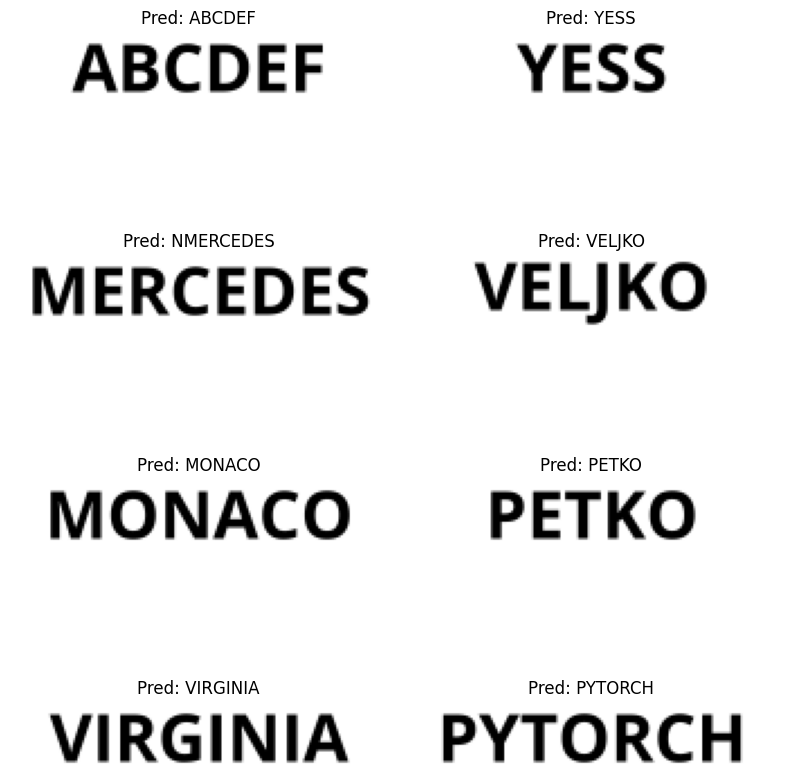

In [5]:
import matplotlib.pyplot as plt

ckpt = torch.load(CHECKPOINT, map_location=DEVICE)
num_classes = 1 + len(ALPHABET)
model = CRNN(num_classes)
model.load_state_dict(ckpt["model"])
model.to(DEVICE)
model.eval()
tf = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((IMG_H, IMG_W)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

image_paths = [f"dataset/testing_images/{i}.png" for i in range(1, 9)]

images = []
predictions = []

for p in image_paths:
    img = Image.open(p).convert("L")
    x = tf(img).unsqueeze(0).to(DEVICE)  # [1,1,32,168]

    with torch.no_grad():
        logits = model(x)
        pred_text = greedy_decode(logits)

    images.append(img)
    predictions.append(pred_text)

fig, axes = plt.subplots(4, 2, figsize=(8, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.imshow(images[i], cmap="gray")
    ax.set_title(f"Pred: {predictions[i]}", fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()